# Exploration of the Global Land Cover dataset

In [48]:
import os
import numpy as np
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box

In [16]:
GCLC_DIR = "../datasets/GCLC"

## Visualize data

### Plot US map

In [56]:
def plot_gclc_us_majority(gclc_dir, us_bounds=(-125, 24, -66.5, 49)):
    files = sorted([f for f in os.listdir(gclc_dir) if f.endswith('.tif')])
    class_names = [os.path.splitext(f)[0] for f in files]
    if not files:
        print("No .tif files found in directory.")
        return

    with rasterio.open(os.path.join(gclc_dir, files[0])) as ref:
        window = from_bounds(*us_bounds, transform=ref.transform)

    data_stack = []
    fill_value = 255
    for fname in files:
        path = os.path.join(gclc_dir, fname)
        with rasterio.open(path) as ds:
            data = ds.read(1, window=window, masked=True)
            data_stack.append(data.filled(fill_value))

    data_stack = np.stack(data_stack, axis=0).astype(float)
    mask = np.all(data_stack == fill_value, axis=0)
    data_stack[data_stack == fill_value] = -np.inf

    majority_idx = np.argmax(data_stack, axis=0)
    majority_idx[mask] = -1

    # Plot
    plt.figure(figsize=(12, 7))
    cmap = plt.get_cmap('tab20', len(class_names))
    im = plt.imshow(majority_idx, origin="upper", extent=us_bounds, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    # plt.colorbar(im, label="GCLC Majority Class Index")
    plt.title("US Majority Land Cover (GCLC)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Add legend for classes
    handles = [mpatches.Patch(color=cmap(i), label=class_names[i]) for i in range(len(class_names))]
    plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Land Cover Class")

    # plt.tight_layout()
    plt.show()

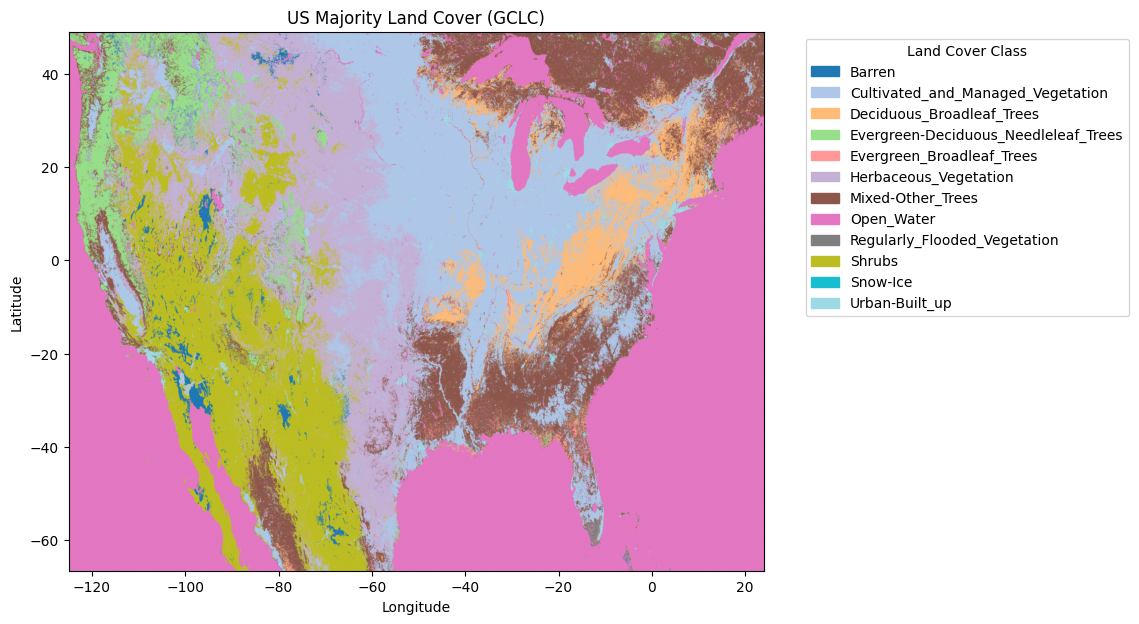

In [57]:
plot_gclc_us_majority(gclc_dir=GCLC_DIR, us_bounds=(-125, 24, -66.5, 49))

### Plot a patch

#### single class

In [ ]:
def plot_gclc_patch(lat, lon, size_km, gclc_dir, landcover_class=None):
    """
    Plot a patch of size_km x size_km km from the GCLC dataset, optionally overlayed on a map.
    If landcover_class is None, plots the first available class.
    """
    half_h = size_km / 111.32
    half_w = size_km / (111.32 * np.cos(np.deg2rad(lat)))
    bounds = (
        lon - half_w,
        lat - half_h,
        lon + half_w,
        lat + half_h
    )

    # Pick a landcover class if not specified
    files = [f for f in os.listdir(gclc_dir) if f.endswith('.tif')]
    if not files:
        print("No .tif files found in directory.")
        return
    if landcover_class is None:
        fname = files[0]
    else:
        fname = f"{landcover_class}.tif"
        if fname not in files:
            print(f"{fname} not found in directory.")
            return

    path = os.path.join(gclc_dir, fname)
    with rasterio.open(path) as ds:
        window = from_bounds(*bounds, ds.transform)
        data = ds.read(1, window=window, masked=True)
        # Get extent in lon/lat for plotting
        left, bottom = bounds[0], bounds[1]
        right, top = bounds[2], bounds[3]
        extent = [left, right, bottom, top]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(data, extent=extent, origin='upper', cmap='viridis', alpha=0.7)
    plt.colorbar(im, ax=ax, label='Landcover %')
    ax.set_title(f"{fname} ({size_km}x{size_km} km patch)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Overlay with a basemap
    try:
        # contextily expects Web Mercator, so convert extent and set CRS
        gdf = gpd.GeoDataFrame({'geometry': [box(*extent)]}, crs="EPSG:4326")
        gdf = gdf.to_crs(epsg=3857)
        ax.set_xlim(*gdf.total_bounds[[0,2]])
        ax.set_ylim(*gdf.total_bounds[[1,3]])
        ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Stamen.TerrainBackground)
    except Exception as e:
        print("Could not add basemap:", e)

    plt.show()

In [ ]:
plot_gclc_patch(
    lat=39.7392, lon=-104.9903,  # Denver
    size_km=10,
    gclc_dir=GCLC_DIR,
    landcover_class='forest'  # or specify a class, e.g. 'forest'
)

forest.tif not found in directory.


#### all classes

In [25]:
def plot_gclc_majority_patch(lat, lon, size_km, gclc_dir, class_colors=None):
    """
    Plot a patch showing the majority land cover class at each pixel.
    """

    # Get all .tif files and class names
    files = sorted([f for f in os.listdir(gclc_dir) if f.endswith('.tif')])
    class_names = [os.path.splitext(f)[0] for f in files]
    if not files:
        print("No .tif files found in directory.")
        return

    # Calculate bounds
    half_h = size_km / 111.32
    half_w = size_km / (111.32 * np.cos(np.deg2rad(lat)))
    bounds = (
        lon - half_w,
        lat - half_h,
        lon + half_w,
        lat + half_h
    )

    # Read all class data into a stack
    data_stack = []
    fill_value = 255  # valid for uint8, and likely unused as a percentage
    for fname in files:
        path = os.path.join(gclc_dir, fname)
        with rasterio.open(path) as ds:
            window = from_bounds(*bounds, ds.transform)
            data = ds.read(1, window=window, masked=True)
            data_stack.append(data.filled(fill_value))  # fill masked with 255

    data_stack = np.stack(data_stack, axis=0).astype(float)  # ensure float type
    # Mask out pixels where all classes are masked
    mask = np.all(data_stack == fill_value, axis=0)
    data_stack[data_stack == fill_value] = -np.inf  # so they never win

    # Find majority class index at each pixel
    majority_idx = np.argmax(data_stack, axis=0)
    majority_idx[mask] = -1  # set masked pixels to -1

    # Color map for classes
    if class_colors is None:
        cmap = plt.get_cmap('tab20', len(class_names))
        class_colors = [cmap(i) for i in range(len(class_names))]
    else:
        cmap = None

    # Plot
    left, bottom = bounds[0], bounds[1]
    right, top = bounds[2], bounds[3]
    extent = [left, right, bottom, top]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(majority_idx, extent=extent, origin='upper', cmap=cmap, vmin=0, vmax=len(class_names)-1)
    ax.set_title(f"Majority Land Cover Class ({size_km}x{size_km} km patch)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Legend
    handles = [mpatches.Patch(color=class_colors[i], label=class_names[i]) for i in range(len(class_names))]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Overlay with a basemap
    try:
        gdf = gpd.GeoDataFrame({'geometry': [box(*extent)]}, crs="EPSG:4326")
        gdf = gdf.to_crs(epsg=3857)
        ax.set_xlim(*gdf.total_bounds[[0,2]])
        ax.set_ylim(*gdf.total_bounds[[1,3]])
        ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Stamen.TerrainBackground)
    except Exception as e:
        print("Could not add basemap:", e)

    plt.tight_layout()
    plt.show()

Could not add basemap: Axis limits cannot be NaN or Inf


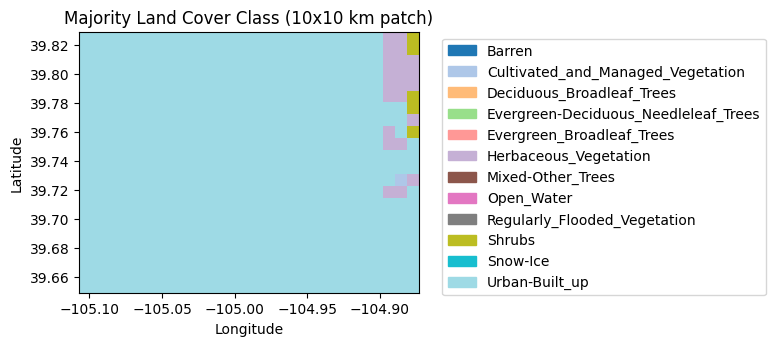

In [26]:
plot_gclc_majority_patch(
    lat=39.7392, lon=-104.9903,  # Denver
    size_km=10,
    gclc_dir=GCLC_DIR
)

## Average coverage per point

In [3]:
def gclc_features(
    lat,
    lon,
    radius_km,
    gclc_dir,
    agg="mean"
):
    """
    Compute land cover percentages from Global 1km Consensus Land Cover.

    Parameters
    ----------
    lat, lon : float
        Latitude and longitude in degrees.
    radius_km : float
        Radius of square window in kilometers.
    gclc_dir : str
        Directory containing GCLC .tif files.
    agg : str
        Aggregation method: 'mean', 'sum', 'median'.

    Returns
    -------
    dict
        {landcover_class: aggregated_percentage}
    """

    # --- km -> degrees ---
    half_h = radius_km / 111.32
    half_w = radius_km / (111.32 * np.cos(np.deg2rad(lat)))

    bounds = (
        lon - half_w,
        lat - half_h,
        lon + half_w,
        lat + half_h
    )

    results = {}

    for fname in os.listdir(gclc_dir):
        if not fname.endswith(".tif"):
            continue

        lc_name = os.path.splitext(fname)[0]

        with rasterio.open(os.path.join(gclc_dir, fname)) as ds:
            window = from_bounds(*bounds, ds.transform)
            data = ds.read(1, window=window, masked=True)

            if data.mask.all():
                value = np.nan
            else:
                if agg == "mean":
                    value = data.mean()
                elif agg == "sum":
                    value = data.sum()
                elif agg == "median":
                    value = np.median(data.compressed())
                else:
                    raise ValueError(f"Unknown agg: {agg}")

        results[lc_name] = float(value)

    return results


In [ ]:
features = gclc_features(
    lat=39.7392,
    lon=-104.9903,   # Denver
    radius_km=10,
    gclc_dir=GCLC_DIR,
    agg="mean"
)

print(features)

{'Barren': 0.18344155844155843, 'Cultivated_and_Managed_Vegetation': 4.233766233766234, 'Deciduous_Broadleaf_Trees': 0.11363636363636363, 'Evergreen-Deciduous_Needleleaf_Trees': 11.198051948051948, 'Evergreen_Broadleaf_Trees': 1.2321428571428572, 'Herbaceous_Vegetation': 3.814935064935065, 'Mixed-Other_Trees': 6.2272727272727275, 'Open_Water': 0.387987012987013, 'Regularly_Flooded_Vegetation': 0.0, 'Shrubs': 4.753246753246753, 'Snow-Ice': 0.0, 'Urban-Built_up': 67.85551948051948}
